<a href="https://colab.research.google.com/github/Taha-Rahim/Process-Instrumentation-AI/blob/main/predictive_maintenance_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚙️ Process Instrumentation: Automated Anomaly Detection
**Project Objective:** To design a software-based fault detection system for a thermal process using dynamic statistical thresholds.

### Core Engineering Concepts Demonstrated:
* **Process Simulation:** Generating synthetic process variables (PV) with real-world sensor noise.
* **Signal Processing:** Filtering high-frequency interference to stabilize control data.
* **Predictive Maintenance:** Moving beyond hard-coded alarms by implementing dynamic fault detection to catch mechanical drift (e.g., a sticking cooling valve) before catastrophic failure.

---

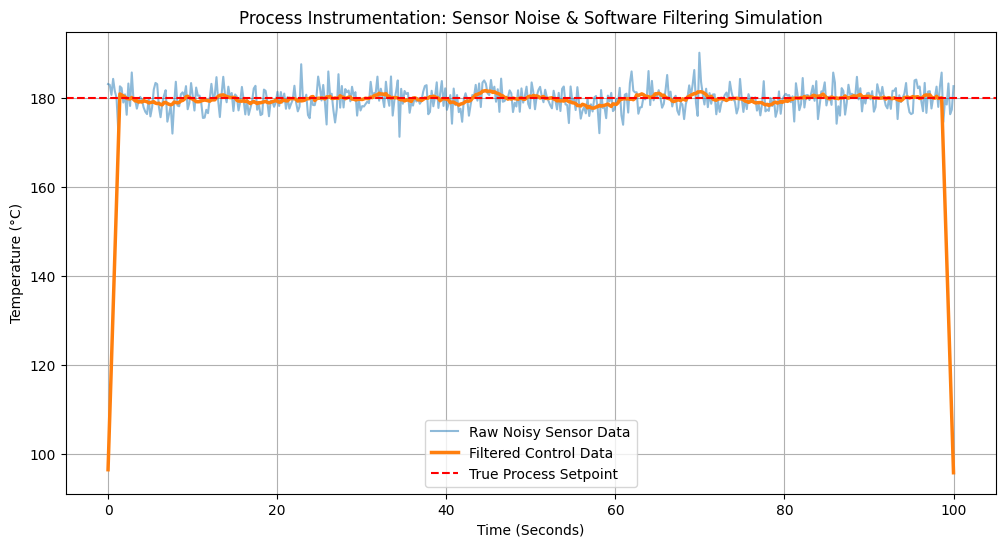

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Simulate a true, stable process temperature (e.g., a chemical reactor at 180°C)
time = np.linspace(0, 100, 500)
true_temperature = 180.0

# 2. Simulate high-frequency industrial noise (e.g., electromagnetic interference on the sensor cable)
# We add random normal noise to the true value
noise = np.random.normal(0, 2.5, size=len(time))
sensor_reading = true_temperature + noise

# 3. Apply a software filter (Moving Average) to clean the instrumentation data
# This simulates how a digital controller smooths out raw input
window_size = 15
filtered_reading = np.convolve(sensor_reading, np.ones(window_size)/window_size, mode='same')

# 4. Plot the results to visualize the system
plt.figure(figsize=(12, 6))
plt.plot(time, sensor_reading, label='Raw Noisy Sensor Data', alpha=0.5)
plt.plot(time, filtered_reading, label='Filtered Control Data', linewidth=2.5)
plt.axhline(y=true_temperature, color='r', linestyle='--', label='True Process Setpoint')

plt.title('Process Instrumentation: Sensor Noise & Software Filtering Simulation')
plt.xlabel('Time (Seconds)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()

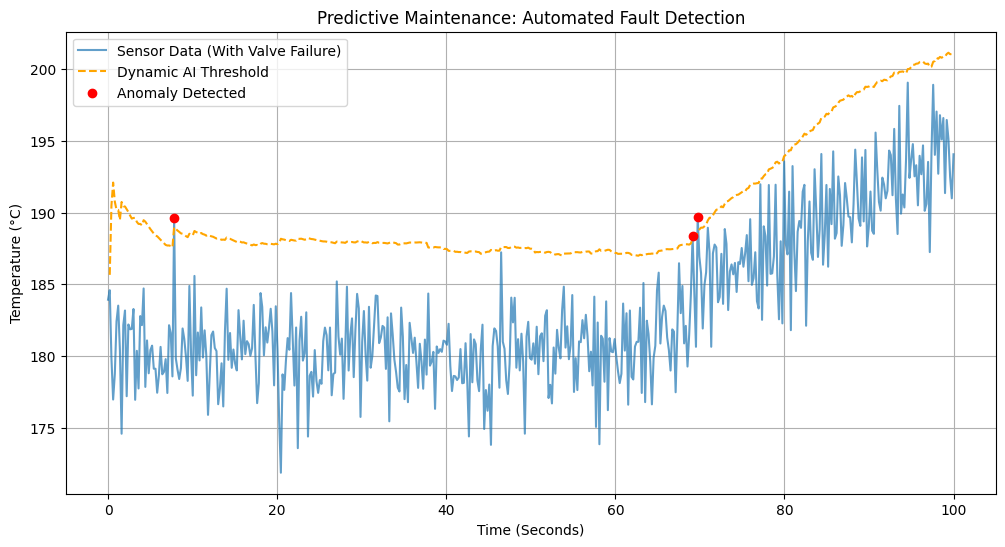

In [11]:
import pandas as pd

# 1. We start with the same stable process, but this time...
time = np.linspace(0, 100, 500)
true_temperature = 180.0
sensor_reading = true_temperature + np.random.normal(0, 2.5, size=len(time))

# 2. INJECT A FAILURE: At the 60-second mark (index 300), the cooling valve sticks!
# The temperature starts to drift upward steadily.
sensor_reading[300:] += np.linspace(0, 15, 200)

# 3. AI/ML CONCEPT: Fixing the "Boiling Frog" effect
# We increase the window size from 20 to 150 so the model "remembers" the stable state longer.
data_series = pd.Series(sensor_reading)

# min_periods=1 prevents the orange line from disappearing at the beginning of the graph
rolling_mean = data_series.rolling(window=150, min_periods=1).mean()
rolling_std = data_series.rolling(window=150, min_periods=2).std()

# We lower the strictness slightly to 2.5 standard deviations for earlier detection
upper_bound = rolling_mean + (2.5 * rolling_std)
anomalies = sensor_reading > upper_bound

# Define an anomaly as anything 3 standard deviations above the recent norm
upper_bound = rolling_mean + (3 * rolling_std)
anomalies = sensor_reading > upper_bound

# 4. Plot the results
plt.figure(figsize=(12, 6))
plt.plot(time, sensor_reading, label='Sensor Data (With Valve Failure)', alpha=0.7)
plt.plot(time, upper_bound, label='Dynamic AI Threshold', color='orange', linestyle='--')

# Highlight the exact moments the algorithm detected an anomaly
plt.scatter(time[anomalies], sensor_reading[anomalies], color='red', label='Anomaly Detected', zorder=5)

plt.title('Predictive Maintenance: Automated Fault Detection')
plt.xlabel('Time (Seconds)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()

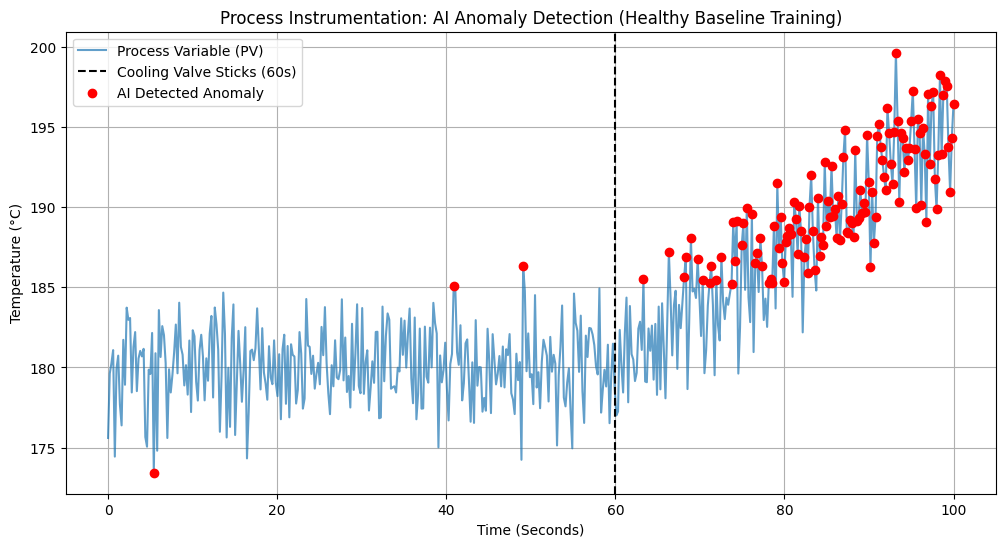

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# ---------------------------------------------------------
# PHASE 1: SIMULATE THE PHYSICAL PROCESS & FAILURE
# ---------------------------------------------------------
time = np.linspace(0, 100, 500)
true_setpoint = 180.0

# Add standard electrical/sensor noise to our 180 degree baseline
sensor_reading = true_setpoint + np.random.normal(0, 2.5, size=len(time))

# THE FAILURE: At the 60-second mark (index 300), the cooling valve sticks.
# We force the temperature to ramp up by 15 degrees over the rest of the simulation.
sensor_reading[300:] += np.linspace(0, 15, 200)

# Reshape the 1D list into a 2D column so the ML algorithm can read it
data_for_ml = sensor_reading.reshape(-1, 1)


# ---------------------------------------------------------
# PHASE 2: MACHINE LEARNING LOGIC (The Fix)
# ---------------------------------------------------------
# CRITICAL STEP: We only give the AI the first 50 seconds (250 points) to learn from.
# This ensures it only learns what a "Healthy" machine looks like.
healthy_training_data = data_for_ml[:250]

# Initialize the Isolation Forest
# We lower contamination to 0.01 because healthy data should have very few anomalies
ml_model = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)

# TRAIN the model on the healthy baseline
ml_model.fit(healthy_training_data)

# PREDICT anomalies across the entire 100-second timeline
# The model will flag anything that doesn't look like the first 50 seconds
predictions = ml_model.predict(data_for_ml)

# The model outputs '1' for normal behavior, and '-1' for anomalies
anomalies_ml = predictions == -1


# ---------------------------------------------------------
# PHASE 3: VISUALIZE THE RESULTS
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

# Plot the raw sensor data
plt.plot(time, sensor_reading, label='Process Variable (PV)', alpha=0.7)

# Draw a vertical line showing exactly when the physical failure occurs
plt.axvline(x=60, color='black', linestyle='--', label='Cooling Valve Sticks (60s)')

# Highlight every point the AI flags as an anomaly
plt.scatter(time[anomalies_ml], sensor_reading[anomalies_ml], color='red', label='AI Detected Anomaly', zorder=5)

plt.title('Process Instrumentation: AI Anomaly Detection (Healthy Baseline Training)')
plt.xlabel('Time (Seconds)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import ipywidgets as widgets
from IPython.display import display, clear_output
import time

# ---------------------------------------------------------
# PHASE 1: SIMULATE THE DATA & TRAIN THE AI (Fast/Invisible)
# ---------------------------------------------------------
time_arr = np.linspace(0, 100, 500)
true_setpoint = 180.0
sensor_reading = true_setpoint + np.random.normal(0, 2.5, size=len(time_arr))
sensor_reading[300:] += np.linspace(0, 15, 200) # Valve sticks at 60s

data_for_ml = sensor_reading.reshape(-1, 1)
healthy_training_data = data_for_ml[:250]

ml_model = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
ml_model.fit(healthy_training_data)
predictions = ml_model.predict(data_for_ml)
anomalies_ml = predictions == -1

# Calculate the "Normal Band" for visual reference based on healthy data
normal_max = healthy_training_data.max()
normal_min = healthy_training_data.min()

# ---------------------------------------------------------
# PHASE 2: THE LIVE DASHBOARD INTERFACE
# ---------------------------------------------------------
button = widgets.Button(
    description='▶ Start Simulation',
    button_style='success',
    tooltip='Click to run the live process simulation'
)
output = widgets.Output()
display(button, output)

def run_simulation(b):
    with output:
        anomaly_count = 0

        # We process the data in chunks of 10 to make the animation smooth
        for i in range(10, len(time_arr) + 1, 10):
            clear_output(wait=True)

            # Slice the data up to the current "live" moment
            current_time = time_arr[:i]
            current_sensor = sensor_reading[:i]
            current_anomalies = anomalies_ml[:i]

            # Update anomaly count
            anomaly_count = np.sum(current_anomalies)

            # Print the Live Status Dashboard above the graph
            print(f"⏱️ System Time: {current_time[-1]:.1f} Seconds")
            if anomaly_count > 0:
                print(f"⚠️ SYSTEM WARNING: {anomaly_count} Anomalies Detected!")
                print(f"🚨 LATEST FAULT AT: {current_time[current_anomalies][-1]:.1f}s | Reading: {current_sensor[current_anomalies][-1]:.1f}°C")
            else:
                print("✅ System Status: NORMAL")
                print("---")

            # Draw the Graph
            plt.figure(figsize=(12, 6))

            # Draw the green "Normal Operating Band"
            plt.fill_between(time_arr, normal_min, normal_max, color='green', alpha=0.1, label='AI Learned Normal Band')

            # Plot the live sensor line
            plt.plot(current_time, current_sensor, color='steelblue', label='Live Process Variable', linewidth=1.5)

            # Draw the red dots if anomalies exist in the current timeframe
            if anomaly_count > 0:
                plt.scatter(current_time[current_anomalies], current_sensor[current_anomalies], color='red', s=50, label='Anomaly Trigger', zorder=5)

            # Keep the axes fixed so the graph doesn't jump around
            plt.xlim(0, 100)
            plt.ylim(170, 205)
            plt.title('Live HMI Dashboard: AI Predictive Maintenance')
            plt.xlabel('Time (Seconds)')
            plt.ylabel('Temperature (°C)')
            plt.legend(loc='upper left')
            plt.grid(True)
            plt.show()

            # Pause briefly to create the animation effect
            time.sleep(0.1)

# Link the button to the function
button.on_click(run_simulation)

Button(button_style='success', description='▶ Start Simulation', style=ButtonStyle(), tooltip='Click to run th…

Output()

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import ipywidgets as widgets
from IPython.display import display, clear_output
import time

# ---------------------------------------------------------
# PHASE 1: SIMULATE DATA & TRAIN THE AI (Healthy Baseline)
# ---------------------------------------------------------
time_arr = np.linspace(0, 100, 500)
true_setpoint = 180.0
sensor_reading = true_setpoint + np.random.normal(0, 2.5, size=len(time_arr))

# Simulate the cooling valve sticking at 60s
sensor_reading[300:] += np.linspace(0, 20, 200)

# Train the AI strictly on the first 50 seconds (Healthy Data)
data_for_ml = sensor_reading.reshape(-1, 1)
healthy_training_data = data_for_ml[:250]
ml_model = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
ml_model.fit(healthy_training_data)

# Calculate Normal Band for visuals
normal_max = healthy_training_data.max()
normal_min = healthy_training_data.min()

# ---------------------------------------------------------
# PHASE 2: UI DASHBOARD SETUP (Fixing the Flicker)
# ---------------------------------------------------------
button = widgets.Button(description='▶ Start Simulation', button_style='success')
status_board = widgets.HTML(value="<b>System Status:</b> Ready to Start")
plot_output = widgets.Output()
display(button, status_board, plot_output)

def run_simulation(b):
    button.disabled = True
    consecutive_faults = 0
    emergency_shutdown = False

    with plot_output:
        for i in range(10, len(time_arr) + 1, 10):
            # 1. FETCH CURRENT DATA
            current_time = time_arr[:i]

            # 2. THE AI PREDICTION (Checking the latest point)
            latest_point = sensor_reading[i-1].reshape(1, -1)
            is_anomaly = ml_model.predict(latest_point)[0] == -1

            # 3. SAFETY INTERLOCK LOGIC (Taking Action!)
            if is_anomaly:
                consecutive_faults += 1
            else:
                consecutive_faults = 0 # Reset if it was just a random noise spike

            # If 5 faults happen in a row, trigger the shutdown
            if consecutive_faults >= 5 and not emergency_shutdown:
                emergency_shutdown = True
                shutdown_time = current_time[-1]

                # OVERRIDE THE PHYSICAL SYSTEM:
                # Simulate the heaters turning off and the temperature rapidly dropping
                for j in range(i, len(time_arr)):
                    # Mathematical cooling curve towards ambient (25°C)
                    sensor_reading[j] = 25.0 + (sensor_reading[i-1] - 25.0) * np.exp(-0.1 * (time_arr[j] - shutdown_time))

            # Slice the updated data
            current_sensor = sensor_reading[:i]

            # 4. UPDATE DASHBOARD TEXT
            if emergency_shutdown:
                status_board.value = f"<h3 style='color:red;'>🚨 EMERGENCY SHUTDOWN INITIATED 🚨</h3><p>Critical failure detected at {shutdown_time:.1f}s. System overridden to prevent damage.</p>"
            elif is_anomaly:
                status_board.value = f"<h3 style='color:orange;'>⚠️ WARNING</h3><p>Consecutive Faults: {consecutive_faults}/5. Investigating...</p>"
            else:
                status_board.value = f"<h3 style='color:green;'>✅ NORMAL</h3><p>System Operating at {current_sensor[-1]:.1f}°C</p>"

            # 5. RENDER THE GRAPH
            clear_output(wait=True)
            plt.figure(figsize=(12, 6))
            plt.fill_between(time_arr, normal_min, normal_max, color='green', alpha=0.1, label='Normal Band')

            # Draw the process variable
            if emergency_shutdown:
                 plt.plot(current_time, current_sensor, color='red', label='Emergency Cooling Curve', linewidth=2.5)
            else:
                 plt.plot(current_time, current_sensor, color='steelblue', label='Live PV', linewidth=1.5)

            plt.xlim(0, 100)
            plt.ylim(100, 210)
            plt.title('Live HMI Dashboard with Automated Safety Interlocks')
            plt.xlabel('Time (Seconds)')
            plt.ylabel('Temperature (°C)')
            plt.legend(loc='upper left')
            plt.grid(True)
            plt.show()

            time.sleep(0.1) # Controls animation speed

button.on_click(run_simulation)

Button(button_style='success', description='▶ Start Simulation', style=ButtonStyle())

HTML(value='<b>System Status:</b> Ready to Start')

Output()

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import ipywidgets as widgets
from IPython.display import display, clear_output
import time

# ---------------------------------------------------------
# PHASE 1: SIMULATE DATA & TRAIN THE AI
# ---------------------------------------------------------
time_arr = np.linspace(0, 100, 500)
true_setpoint = 180.0
sensor_reading = true_setpoint + np.random.normal(0, 2.5, size=len(time_arr))
sensor_reading[300:] += np.linspace(0, 20, 200)

data_for_ml = sensor_reading.reshape(-1, 1)
healthy_training_data = data_for_ml[:250]
ml_model = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
ml_model.fit(healthy_training_data)

normal_max = healthy_training_data.max()
normal_min = healthy_training_data.min()

# ---------------------------------------------------------
# PHASE 2: UI DASHBOARD & DYNAMIC VISUALS
# ---------------------------------------------------------
button = widgets.Button(description='▶ Start Simulation', button_style='success')
status_board = widgets.HTML(value="<b>System Status:</b> Ready to Start")
plot_output = widgets.Output()
display(button, status_board, plot_output)

def run_simulation(b):
    button.disabled = True
    consecutive_faults = 0
    emergency_shutdown = False
    shutdown_time = None
    warning_start_time = None

    with plot_output:
        for i in range(10, len(time_arr) + 1, 10):
            current_time = time_arr[:i]

            # AI Prediction
            latest_point = sensor_reading[i-1].reshape(1, -1)
            is_anomaly = ml_model.predict(latest_point)[0] == -1

            # Interlock Logic & State Tracking
            if is_anomaly and not emergency_shutdown:
                consecutive_faults += 1
                if consecutive_faults == 1:
                    warning_start_time = current_time[-1]
            elif not emergency_shutdown:
                consecutive_faults = 0
                warning_start_time = None

            if consecutive_faults >= 5 and not emergency_shutdown:
                emergency_shutdown = True
                shutdown_time = current_time[-1]

                # Apply cooling curve
                for j in range(i, len(time_arr)):
                    sensor_reading[j] = 25.0 + (sensor_reading[i-1] - 25.0) * np.exp(-0.15 * (time_arr[j] - shutdown_time))

            current_sensor = sensor_reading[:i]

            # Get all anomalies up to current time to plot the dots
            current_anomalies = ml_model.predict(current_sensor.reshape(-1, 1)) == -1

            # Update Text Board
            if emergency_shutdown:
                status_board.value = f"<h3 style='color:red;'>🚨 EMERGENCY SHUTDOWN INITIATED 🚨</h3><p>Tripped at {shutdown_time:.1f}s | Cooling sequence active.</p>"
            elif consecutive_faults > 0:
                status_board.value = f"<h3 style='color:#d4a017;'>⚠️ WARNING</h3><p>Consecutive Faults: {consecutive_faults}/5 | Temperature Rising!</p>"
            else:
                status_board.value = f"<h3 style='color:green;'>✅ NORMAL</h3><p>Live PV: {current_sensor[-1]:.1f}°C</p>"

            # ---------------------------------------------------------
            # PHASE 3: AESTHETIC RENDERING
            # ---------------------------------------------------------
            clear_output(wait=True)
            plt.figure(figsize=(12, 6))

            # Backgrounds
            plt.fill_between(time_arr, normal_min, normal_max, color='#e0f2f1', alpha=0.5, label='Safe Operating Band')
            plt.axhspan(normal_max, 210, color='#ffebee', alpha=0.3) # Danger zone background

            # Plot the line dynamically based on state
            if emergency_shutdown:
                # 1. Normal (Green) up to warning
                idx_warn = np.where(current_time == warning_start_time)[0][0] if warning_start_time else len(current_time)
                idx_shut = np.where(current_time == shutdown_time)[0][0]

                plt.plot(current_time[:idx_warn], current_sensor[:idx_warn], color='#2e7d32', linewidth=1.2, label='Nominal Run')
                plt.plot(current_time[idx_warn-1:idx_shut], current_sensor[idx_warn-1:idx_shut], color='#f57f17', linewidth=2, label='Degraded State')
                plt.plot(current_time[idx_shut-1:], current_sensor[idx_shut-1:], color='#c62828', linewidth=2.5, label='Shutdown Sequence')

                # Shutdown visual indicators
                plt.axvspan(shutdown_time, 100, color='#ffebee', alpha=0.8)
                plt.axvline(x=shutdown_time, color='red', linestyle='--', linewidth=1.5)
                plt.text(shutdown_time + 2, 160, f"SYSTEM TRIPPED\n@ {shutdown_time:.1f}s", color='darkred', fontsize=12, fontweight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='red'))

            elif consecutive_faults > 0:
                idx_warn = np.where(current_time == warning_start_time)[0][0]
                plt.plot(current_time[:idx_warn], current_sensor[:idx_warn], color='#2e7d32', linewidth=1.2, label='Nominal Run')
                plt.plot(current_time[idx_warn-1:], current_sensor[idx_warn-1:], color='#f57f17', linewidth=2, label='Degraded State')
            else:
                plt.plot(current_time, current_sensor, color='#2e7d32', linewidth=1.2, label='Nominal Run')

            # Draw Anomaly Dots
            if np.any(current_anomalies):
                plt.scatter(current_time[current_anomalies], current_sensor[current_anomalies], color='red', s=35, edgecolor='black', zorder=5, label='AI Flag')

            # Overlay Information Text Box
            info_text = f"Live PV: {current_sensor[-1]:.1f}°C\nPeak PV: {current_sensor.max():.1f}°C"
            plt.text(2, 200, info_text, fontsize=10, bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray'))

            # Graph Formatting
            plt.xlim(0, 100)
            plt.ylim(100, 210)
            plt.title('HMI Dashboard: AI-Driven Process Interlock', fontsize=14, fontweight='bold')
            plt.xlabel('Time (Seconds)', fontsize=11)
            plt.ylabel('Temperature (°C)', fontsize=11)

            # Clean up the legend to avoid duplicates
            handles, labels = plt.gca().get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            plt.legend(by_label.values(), by_label.keys(), loc='lower left')

            plt.grid(True, linestyle='--', alpha=0.6)
            plt.show()

            time.sleep(0.1)

button.on_click(run_simulation)

Button(button_style='success', description='▶ Start Simulation', style=ButtonStyle())

HTML(value='<b>System Status:</b> Ready to Start')

Output()

## Phase 2: AI-Triggered Closed-Loop Control (PID)
Instead of initiating a hard system shutdown upon detecting a mechanical failure, this phase implements a Proportional-Integral-Derivative (PID) controller. The AI intercepts the anomalous drift and dynamically modulates the heater output to counteract the cooling loss, stabilizing the system without halting production.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import ipywidgets as widgets
from IPython.display import display, clear_output
import time

# ---------------------------------------------------------
# PHASE 1: AI TRAINING (Healthy Baseline)
# ---------------------------------------------------------
time_arr = np.linspace(0, 100, 500)
true_setpoint = 180.0

healthy_baseline = true_setpoint + np.random.normal(0, 2.5, 250)
ml_model = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
ml_model.fit(healthy_baseline.reshape(-1, 1))

normal_max = healthy_baseline.max()
normal_min = healthy_baseline.min()

# ---------------------------------------------------------
# PHASE 2: PHYSICS SIMULATION WITH CASCADING SAFETY
# ---------------------------------------------------------
button = widgets.Button(description='▶ Start Cascade Control Loop', button_style='info')
status_board = widgets.HTML(value="<b>System Status:</b> Ready to Start")
plot_output = widgets.Output()
display(button, status_board, plot_output)

def run_simulation(b):
    button.disabled = True
    consecutive_faults = 0
    pid_active = False
    emergency_shutdown = False
    shutdown_time = None

    # PI Tuning Parameters
    Kp = 0.5
    Ki = 0.05
    integral_error = 0

    live_time = []
    live_temp = []
    live_heater = []

    current_temp = 180.0
    heater_output = 50.0

    with plot_output:
        for i in range(len(time_arr)):
            current_t = time_arr[i]
            live_time.append(current_t)

            # --- 1. SIMULATE REACTOR PHYSICS ---
            if emergency_shutdown:
                # Emergency Cooling Mode active
                heating_effect = 0
                ambient_cooling = 5.0
                valve_failure_effect = 0
                current_temp = 25.0 + (current_temp - 25.0) * np.exp(-0.15 * (current_t - shutdown_time))
                sensor_reading = current_temp + np.random.normal(0, 1.0)
                heater_output = 0.0
            else:
                # Standard Operation Mode
                ambient_cooling = 5.0
                heating_effect = heater_output * 0.1

                valve_failure_effect = 0
                if current_t >= 60.0:
                    valve_failure_effect = (current_t - 60.0) * 0.15

                current_temp = current_temp + heating_effect - ambient_cooling + valve_failure_effect
                sensor_reading = current_temp + np.random.normal(0, 2.5)

            live_temp.append(sensor_reading)
            live_heater.append(heater_output)

            # --- 2. AI ANOMALY DETECTION ---
            latest_point = np.array([[sensor_reading]])
            is_anomaly = ml_model.predict(latest_point)[0] == -1

            # --- 3. CASCADING CONTROL & SAFETY LOGIC ---
            if is_anomaly and not pid_active and not emergency_shutdown:
                consecutive_faults += 1
                if consecutive_faults >= 5:
                    pid_active = True

            # PID Modulating State
            if pid_active and not emergency_shutdown:
                error = true_setpoint - sensor_reading

                if 0.0 < heater_output < 100.0:
                    integral_error += error

                heater_output = 50.0 + (Kp * error) + (Ki * integral_error)
                heater_output = max(0.0, min(100.0, heater_output))

                # ESCALATION CRITERIA: If heater is bottomed out at 0% and temp escapes above 192°C, pull the plug!
                if heater_output == 0.0 and sensor_reading > 192.0:
                    emergency_shutdown = True
                    pid_active = False
                    shutdown_time = current_t

            # --- 4. RENDER DASHBOARD ---
            if i % 10 == 0 and i > 0:
                clear_output(wait=True)

                fig, ax1 = plt.subplots(figsize=(12, 6))
                ax2 = ax1.twinx()

                # Draw safe background zone
                ax1.fill_between(live_time, normal_min, normal_max, color='#e0f2f1', alpha=0.5, label='Safe Band')

                # Draw main process variables
                ax1.plot(live_time, live_temp, color='#2e7d32', linewidth=1.5, label='Live PV (°C)')
                ax2.plot(live_time, live_heater, color='#d84315', linewidth=2, linestyle='--', label='Heater Power (%)')

                # Post-shutdown visual shading
                if emergency_shutdown:
                    ax1.axvspan(shutdown_time, 100, color='#ffebee', alpha=0.8)
                    ax1.axvline(x=shutdown_time, color='red', linestyle='--', linewidth=1.5)
                    ax1.text(shutdown_time + 2, 165, f"CRITICAL ESCALATION\nSHUTDOWN @ {shutdown_time:.1f}s", color='darkred', fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='red'))
                    status_board.value = f"<h3 style='color:red;'>🚨 CASCADE TRIP: SYSTEM SHUTDOWN 🚨</h3><p>PID mitigation saturated at 0% power. Safety interlock executed emergency dump.</p>"
                elif pid_active:
                    status_board.value = f"<h3 style='color:#1565c0;'>🔄 PID MITIGATION ACTIVE 🔄</h3><p>AI intercepted drift. Modulating heater to stabilize process.</p>"
                else:
                    status_board.value = f"<h3 style='color:green;'>✅ NORMAL</h3><p>Live PV: {sensor_reading:.1f}°C | Heater Output: {heater_output:.1f}%</p>"

                ax1.set_xlim(0, 100)
                ax1.set_ylim(160, 210)
                ax2.set_ylim(0, 105)

                ax1.set_title('Integrated AI Control & Saturated Interlock Cascade', fontsize=14, fontweight='bold')
                ax1.set_xlabel('Time (Seconds)', fontsize=11)
                ax1.set_ylabel('Process Temperature (°C)', color='#2e7d32', fontsize=12, fontweight='bold')
                ax2.set_ylabel('Control Variable (Heater %)', color='#d84315', fontsize=12, fontweight='bold')

                lines_1, labels_1 = ax1.get_legend_handles_labels()
                lines_2, labels_2 = ax2.get_legend_handles_labels()
                ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='lower left')

                ax1.grid(True, linestyle='--', alpha=0.6)
                plt.show()
                time.sleep(0.1)

button.on_click(run_simulation)

Button(button_style='info', description='▶ Start Cascade Control Loop', style=ButtonStyle())

HTML(value='<b>System Status:</b> Ready to Start')

Output()

## Phase 3: Fault-Tolerant Redundant Control
This phase introduces a secondary control loop (Override Control). If the primary actuator (heater) reaches saturation at 0% power and the Process Variable (PV) continues to climb, the supervisor logic automatically engages an auxiliary cooling pump. This redundancy prevents the need for an emergency shutdown, allowing the plant to continue operations safely despite the mechanical failure.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import ipywidgets as widgets
from IPython.display import display, clear_output
import time

# ---------------------------------------------------------
# PHASE 1: AI TRAINING (Healthy Baseline)
# ---------------------------------------------------------
time_arr = np.linspace(0, 100, 500)
true_setpoint = 180.0

healthy_baseline = true_setpoint + np.random.normal(0, 2.5, 250)
ml_model = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
ml_model.fit(healthy_baseline.reshape(-1, 1))

normal_max = healthy_baseline.max()
normal_min = healthy_baseline.min()

# ---------------------------------------------------------
# PHASE 3: FAULT-TOLERANT REDUNDANT CONTROL (FIXED)
# ---------------------------------------------------------
button = widgets.Button(
    description='▶ Start Fault-Tolerant Loop',
    button_style='success',
    layout=widgets.Layout(width='auto')
)
status_board = widgets.HTML(value="<b>System Status:</b> Ready to Start")
plot_output = widgets.Output()
display(button, status_board, plot_output)

def run_simulation(b):
    button.disabled = True
    consecutive_faults = 0
    pid_active = False
    backup_active = False

    # PI Tuning Parameters for Main Heater
    Kp = 0.5
    Ki = 0.05
    integral_error = 0

    live_time = []
    live_temp = []
    live_heater = []
    live_backup = []

    current_temp = 180.0
    heater_output = 50.0
    backup_cooling_power = 0.0

    with plot_output:
        for i in range(len(time_arr)):
            current_t = time_arr[i]
            live_time.append(current_t)

            # --- 1. SIMULATE REACTOR PHYSICS ---
            ambient_cooling = 5.0
            heating_effect = heater_output * 0.1
            backup_cooling_effect = backup_cooling_power * 0.15 # Backup pump strength

            valve_failure_effect = 0
            if current_t >= 60.0:
                valve_failure_effect = (current_t - 60.0) * 0.15

            current_temp = current_temp + heating_effect - ambient_cooling - backup_cooling_effect + valve_failure_effect
            sensor_reading = current_temp + np.random.normal(0, 2.5)

            live_temp.append(sensor_reading)
            live_heater.append(heater_output)
            live_backup.append(backup_cooling_power)

            # --- 2. AI ANOMALY DETECTION ---
            latest_point = np.array([[sensor_reading]])
            is_anomaly = ml_model.predict(latest_point)[0] == -1

            if is_anomaly and not pid_active:
                consecutive_faults += 1
                if consecutive_faults >= 5:
                    pid_active = True

            # --- 3. OVERRIDE & REDUNDANT CONTROL LOGIC ---
            if pid_active:
                error = true_setpoint - sensor_reading

                if 0.0 < heater_output < 100.0:
                    integral_error += error

                heater_output = 50.0 + (Kp * error) + (Ki * integral_error)
                heater_output = max(0.0, min(100.0, heater_output))

                # SENSOR SUPERVISOR: Fixed Floating-Point Logic
                # If heater is essentially saturated (< 1%) and temp is climbing past 182, engage!
                if (heater_output < 20.0 and sensor_reading > 182.0) or sensor_reading > 186.0:
                    backup_active = True

                # SECONDARY LOOP: Backup Cooling Proportional Control
                if backup_active:
                    backup_error = sensor_reading - true_setpoint
                    if backup_error > 0:
                        backup_cooling_power = backup_error * 5.0 # Proportional gain for the pump
                        backup_cooling_power = max(0.0, min(100.0, backup_cooling_power))
                    else:
                        backup_cooling_power = 0.0

            # --- 4. RENDER DASHBOARD ---
            if i % 10 == 0 and i > 0:
                clear_output(wait=True)

                fig, ax1 = plt.subplots(figsize=(12, 6))
                ax2 = ax1.twinx()

                ax1.fill_between(live_time, normal_min, normal_max, color='#e0f2f1', alpha=0.5, label='Safe Band')

                ax1.plot(live_time, live_temp, color='#2e7d32', linewidth=1.5, label='Live PV (°C)')
                ax2.plot(live_time, live_heater, color='#d84315', linewidth=2, linestyle='--', label='Primary Heater (%)')

                if any(val > 0 for val in live_backup):
                    ax2.plot(live_time, live_backup, color='#0288d1', linewidth=2, linestyle=':', label='Backup Cooler (%)')

                if backup_active:
                    status_board.value = f"<h3 style='color:#0288d1;'>🛡️ REDUNDANT COOLING ACTIVE 🛡️</h3><p>Primary saturated. Auxiliary pump engaged to maintain setpoint.</p>"
                elif pid_active:
                    status_board.value = f"<h3 style='color:#1565c0;'>🔄 PID MITIGATION ACTIVE 🔄</h3><p>AI intercepted drift. Modulating primary heater.</p>"
                else:
                    status_board.value = f"<h3 style='color:green;'>✅ NORMAL</h3><p>Live PV: {sensor_reading:.1f}°C | Heater: {heater_output:.1f}%</p>"

                ax1.set_xlim(0, 100)
                ax1.set_ylim(160, 210)
                ax2.set_ylim(0, 105)

                ax1.set_title('Phase 3: Fault-Tolerant Redundant Control (Software Overrides)', fontsize=14, fontweight='bold')
                ax1.set_xlabel('Time (Seconds)', fontsize=11)
                ax1.set_ylabel('Process Temperature (°C)', color='#2e7d32', fontsize=12, fontweight='bold')
                ax2.set_ylabel('Actuator Output (%)', color='#424242', fontsize=12, fontweight='bold')

                lines_1, labels_1 = ax1.get_legend_handles_labels()
                lines_2, labels_2 = ax2.get_legend_handles_labels()
                ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='lower left')

                ax1.grid(True, linestyle='--', alpha=0.6)
                plt.show()
                time.sleep(0.1)

button.on_click(run_simulation)

Button(button_style='success', description='▶ Start Fault-Tolerant Loop', layout=Layout(width='auto'), style=B…

HTML(value='<b>System Status:</b> Ready to Start')

Output()

## Milestone 2: Multi-Variable System Expansion (3D Physics Engine)

In real-world industrial environments, process variables are highly interconnected. A single mechanical failure rarely affects just one sensor.

To test our AI's ability to detect multi-dimensional anomalies, we are expanding our simulation engine from 1D (Temperature) to a 3D matrix.

**The Simulation Scenario:**
At `t = 60s`, a mechanical fault is introduced, simulating a cooling valve that begins to stick and restrict fluid flow.
*   **Flow Rate (L/min):** Drops as the valve closes.
*   **Pressure (PSI):** Spikes as fluid backs up behind the restriction.
*   **Temperature (°C):** Rises as the system loses cooling capacity.

This code block establishes the base mathematical relationships between these variables before we upgrade the AI to monitor all three simultaneously.

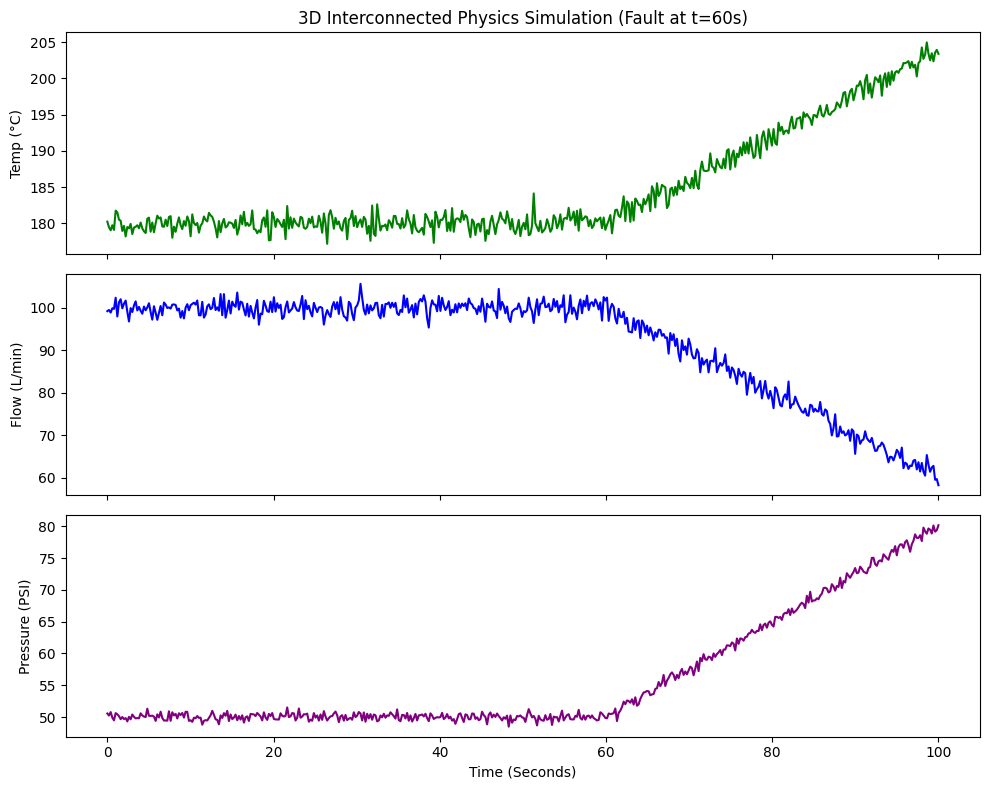

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time

# --- 1. SETPOINTS & BASELINES ---
time_arr = np.linspace(0, 100, 500)
nom_temp = 180.0   # °C
nom_flow = 100.0   # L/min
nom_pressure = 50.0 # PSI

# Arrays to store live data
live_temp = []
live_flow = []
live_pressure = []

# --- 2. PHYSICS SIMULATION LOOP ---
for current_t in time_arr:

    # Base state with natural sensor noise
    current_flow = nom_flow + np.random.normal(0, 1.5)
    current_pressure = nom_pressure + np.random.normal(0, 0.5)
    current_temp = nom_temp + np.random.normal(0, 1.0)

    # Introduce a mechanical fault at t = 60s (Valve Sticking/Blockage)
    if current_t >= 60.0:
        fault_severity = (current_t - 60.0) * 0.5  # Gradually gets worse over time

        # 1. Flow drops as the valve restricts
        current_flow -= fault_severity * 2.0

        # 2. Pressure spikes due to the blockage (inversely related to flow drop)
        current_pressure += fault_severity * 1.5

        # 3. Temperature rises because cooling flow is reduced
        current_temp += fault_severity * 1.2

    # Store the readings
    live_flow.append(current_flow)
    live_pressure.append(current_pressure)
    live_temp.append(current_temp)

# --- 3. QUICK VISUALIZATION CHECK ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax1.plot(time_arr, live_temp, color='green')
ax1.set_ylabel('Temp (°C)')
ax1.set_title('3D Interconnected Physics Simulation (Fault at t=60s)')

ax2.plot(time_arr, live_flow, color='blue')
ax2.set_ylabel('Flow (L/min)')

ax3.plot(time_arr, live_pressure, color='purple')
ax3.set_ylabel('Pressure (PSI)')
ax3.set_xlabel('Time (Seconds)')

plt.tight_layout()
plt.show()

## Upgrading the AI: Multi-Dimensional Anomaly Detection

In the previous phase, the `IsolationForest` model only monitored a single 1D vector (Temperature).

To make the system truly predictive, we are upgrading the AI to monitor a 3D feature space: `[Temperature, Flow Rate, Pressure]`. By training the model on a healthy baseline matrix of all three variables, the AI learns the complex mechanical relationships of the system.

This allows the AI to detect mechanical degradation (like a sticking valve causing a slight pressure bump and flow drop) instantly, providing an early-warning trigger *before* the thermal mass of the system reacts and temperatures rise.

In [3]:
from sklearn.ensemble import IsolationForest

# --- MULTI-DIMENSIONAL AI TRAINING ---

# 1. Generate 300 seconds of "healthy" baseline data for all three sensors
healthy_temp = nom_temp + np.random.normal(0, 1.0, 300)
healthy_flow = nom_flow + np.random.normal(0, 1.5, 300)
healthy_pressure = nom_pressure + np.random.normal(0, 0.5, 300)

# 2. Stack the 1D arrays into a 2D matrix (300 rows x 3 columns)
# This represents [Temp, Flow, Pressure] for every time step
X_train_3d = np.column_stack((healthy_temp, healthy_flow, healthy_pressure))

# 3. Initialize and train the upgraded model
ml_model_3d = IsolationForest(n_estimators=150, contamination=0.01, random_state=42)
ml_model_3d.fit(X_train_3d)

print("✅ 3D AI Model Trained Successfully!")
print(f"Training data shape: {X_train_3d.shape} -> 300 time samples, 3 sensor features.")

✅ 3D AI Model Trained Successfully!
Training data shape: (300, 3) -> 300 time samples, 3 sensor features.


## Live HMI: Multi-Variable AI Monitoring

This interface integrates the 3D physics engine with the trained `IsolationForest` model.

As the simulation runs, the process operates normally until a mechanical restriction (sticking valve) occurs at `t = 60s`. The AI evaluates the `[Temperature, Flow, Pressure]` matrix continuously. By monitoring the complex relationship between flow drops and pressure spikes, the AI can detect mechanical degradation and flag an anomaly before the thermal mass causes a critical temperature breach.

In [4]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import time

# --- HMI DASHBOARD SETUP ---
button_3d = widgets.Button(
    description='▶ Start Multi-Variable Monitoring',
    button_style='primary',
    layout=widgets.Layout(width='auto')
)
status_board_3d = widgets.HTML(value="<b>System Status:</b> Ready to Start")
plot_output_3d = widgets.Output()
display(button_3d, status_board_3d, plot_output_3d)

def run_3d_simulation(b):
    button_3d.disabled = True

    live_time, live_temp, live_flow, live_pressure = [], [], [], []

    # Initial steady states
    c_temp, c_flow, c_press = 180.0, 100.0, 50.0

    with plot_output_3d:
        for i in range(len(time_arr)):
            current_t = time_arr[i]

            # --- 1. SIMULATE INTERCONNECTED PHYSICS ---
            c_flow = nom_flow + np.random.normal(0, 1.5)
            c_press = nom_pressure + np.random.normal(0, 0.5)
            c_temp = nom_temp + np.random.normal(0, 1.0)

            # Introduce the mechanical blockage at t = 60s
            if current_t >= 60.0:
                fault_severity = (current_t - 60.0) * 0.5
                c_flow -= fault_severity * 2.0
                c_press += fault_severity * 1.5
                c_temp += fault_severity * 1.2

            # --- 2. MULTI-DIMENSIONAL AI DETECTION ---
            # Format the latest readings into a 2D matrix for the model
            latest_point = np.array([[c_temp, c_flow, c_press]])
            is_anomaly = ml_model_3d.predict(latest_point)[0] == -1

            live_time.append(current_t)
            live_temp.append(c_temp)
            live_flow.append(c_flow)
            live_pressure.append(c_press)

            # --- 3. UPDATE STATUS BOARD ---
            if is_anomaly:
                status_board_3d.value = f"<h3 style='color:#d84315;'>⚠️ MULTI-VARIABLE ANOMALY DETECTED</h3><p>Mechanical degradation flagged. Flow/Pressure deviation recognized.</p>"
            else:
                status_board_3d.value = f"<h3 style='color:#2e7d32;'>✅ NORMAL</h3><p>All process variables nominal.</p>"

            # --- 4. RENDER LIVE GRAPHS ---
            if i % 10 == 0 and i > 0:
                clear_output(wait=True)
                fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

                ax1.plot(live_time, live_temp, color='#2e7d32', linewidth=1.5)
                ax1.set_ylabel('Temp (°C)', fontweight='bold')
                ax1.set_title('Live 3D AI Process Monitoring', fontsize=14, fontweight='bold')
                ax1.grid(True, linestyle='--', alpha=0.6)

                ax2.plot(live_time, live_flow, color='#0288d1', linewidth=1.5)
                ax2.set_ylabel('Flow (L/min)', fontweight='bold')
                ax2.grid(True, linestyle='--', alpha=0.6)

                ax3.plot(live_time, live_pressure, color='#6a1b9a', linewidth=1.5)
                ax3.set_ylabel('Pressure (PSI)', fontweight='bold')
                ax3.set_xlabel('Time (Seconds)', fontsize=11)
                ax3.grid(True, linestyle='--', alpha=0.6)

                plt.tight_layout()
                plt.show()
                time.sleep(0.1)

button_3d.on_click(run_3d_simulation)

Button(button_style='primary', description='▶ Start Multi-Variable Monitoring', layout=Layout(width='auto'), s…

HTML(value='<b>System Status:</b> Ready to Start')

Output()